In [2]:
import requests
import numpy as np
import pandas as pd, io
from datetime import datetime, timedelta, timezone
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme()

In [4]:
HTTP = "https://api.weather.gc.ca/collections/climate-hourly/items"
start_iso = "2012-07-08T00:00Z"
dt_col = "LOCAL_DATE"

In [5]:
def pull_data(start, dt):
    s = requests.Session()
    s.headers.update({"User-Agent": "bathurst-inlet-hourly-downloader/1.0"})
    start = pd.Timestamp(start, tz="UTC")
    now = pd.Timestamp.now(tz="UTC")

    out = []
    while start < now:
        end = min(now, start + pd.Timedelta(hours=10000-1))
        print(f"start: {start}, end: {end}")
        PARAMS = {
            "f" : "csv", #filetype
            "limit" : "10000",
            "datetime" : f"{start.isoformat()}/{end.isoformat()}", #aug 8 2012 to present
            "CLIMATE_IDENTIFIER" : "2300551",  #Bathurst station id (closest to goose lake)
        }
        r = s.get(HTTP, params=PARAMS, timeout=120)
        r.raise_for_status()

        df = pd.read_csv(io.StringIO(r.text))

        if df.empty:
            break

        df["ts"] = pd.to_datetime(df["LOCAL_DATE"], utc=True)
        df = df.sort_values("ts").reset_index(drop=True)
        

        out.append(df)
        #set last to the max datetime in the df pulled, update start to 1 hour after
        start = end + pd.Timedelta(hours=1)
        if len(df) < 8546:
            break

    concated = pd.concat(out, ignore_index=True)
    concated = concated.sort_values("ts").drop_duplicates(subset=["ts"]).reset_index(drop=True)
    return concated

In [6]:
df = pull_data(start_iso, dt_col)

start: 2012-07-08 00:00:00+00:00, end: 2013-08-28 15:00:00+00:00
start: 2013-08-28 16:00:00+00:00, end: 2014-10-19 07:00:00+00:00
start: 2014-10-19 08:00:00+00:00, end: 2015-12-09 23:00:00+00:00
start: 2015-12-10 00:00:00+00:00, end: 2017-01-29 15:00:00+00:00
start: 2017-01-29 16:00:00+00:00, end: 2018-03-22 07:00:00+00:00
start: 2018-03-22 08:00:00+00:00, end: 2019-05-12 23:00:00+00:00
start: 2019-05-13 00:00:00+00:00, end: 2020-07-02 15:00:00+00:00
start: 2020-07-02 16:00:00+00:00, end: 2021-08-23 07:00:00+00:00
start: 2021-08-23 08:00:00+00:00, end: 2022-10-13 23:00:00+00:00
start: 2022-10-14 00:00:00+00:00, end: 2023-12-04 15:00:00+00:00
start: 2023-12-04 16:00:00+00:00, end: 2025-01-24 07:00:00+00:00
start: 2025-01-24 08:00:00+00:00, end: 2026-03-03 19:51:25.864021+00:00


In [7]:
df.columns

Index(['x', 'y', 'STATION_NAME', 'CLIMATE_IDENTIFIER', 'ID', 'LOCAL_DATE',
       'PROVINCE_CODE', 'LOCAL_YEAR', 'LOCAL_MONTH', 'LOCAL_DAY', 'LOCAL_HOUR',
       'UTC_DATE', 'UTC_YEAR', 'UTC_MONTH', 'UTC_DAY', 'TEMP', 'TEMP_FLAG',
       'DEW_POINT_TEMP', 'DEW_POINT_TEMP_FLAG', 'HUMIDEX', 'HUMIDEX_FLAG',
       'PRECIP_AMOUNT', 'PRECIP_AMOUNT_FLAG', 'RELATIVE_HUMIDITY',
       'RELATIVE_HUMIDITY_FLAG', 'STATION_PRESSURE', 'STATION_PRESSURE_FLAG',
       'VISIBILITY', 'VISIBILITY_FLAG', 'WEATHER_ENG_DESC', 'WEATHER_FRE_DESC',
       'WINDCHILL', 'WINDCHILL_FLAG', 'WIND_DIRECTION', 'WIND_DIRECTION_FLAG',
       'WIND_SPEED', 'WIND_SPEED_FLAG', 'STN_ID', 'LONGITUDE_DECIMAL_DEGREES',
       'LATITUDE_DECIMAL_DEGREES', 'ts'],
      dtype='object')

In [8]:
df = df.drop(columns=['x', 'y', 'PROVINCE_CODE', 'PROVINCE_CODE', 'LOCAL_YEAR', 'LOCAL_MONTH', 'LOCAL_DAY', 'LOCAL_HOUR',
                 'VISIBILITY', 'VISIBILITY_FLAG', 'WEATHER_ENG_DESC', 'WEATHER_FRE_DESC',
                 'STN_ID', 'LONGITUDE_DECIMAL_DEGREES',
       'LATITUDE_DECIMAL_DEGREES', 'TEMP_FLAG', 'RELATIVE_HUMIDITY_FLAG', 'WIND_DIRECTION_FLAG', 'WINDCHILL', 'WINDCHILL_FLAG',
       'STATION_PRESSURE_FLAG', 'WIND_SPEED_FLAG', 'PRECIP_AMOUNT_FLAG', 'DEW_POINT_TEMP_FLAG', 'HUMIDEX_FLAG', 'WIND_SPEED_FLAG'])

In [9]:
df["month"] = df["ts"].dt.month
winter = df[df["month"].isin([12, 1, 2])]
winter["season"] = "winter"
spring = df[df["month"].isin([3, 4, 5])]
spring["season"] = "spring"
summer = df[df["month"].isin([6, 7, 8])]
summer["season"] = "summer"
fall = df[df["month"].isin([9, 10, 11])]
fall["season"] = "fall"

/var/folders/zh/r215ddf530q6945tp1lbn42h0000gn/T/ipykernel_46667/1791209642.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winter["season"] = "winter"
/var/folders/zh/r215ddf530q6945tp1lbn42h0000gn/T/ipykernel_46667/1791209642.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spring["season"] = "spring"
/var/folders/zh/r215ddf530q6945tp1lbn42h0000gn/T/ipykernel_46667/1791209642.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

-51.77063551424176
-57.39376321943085
-11.738877743412385
-43.82409501559038


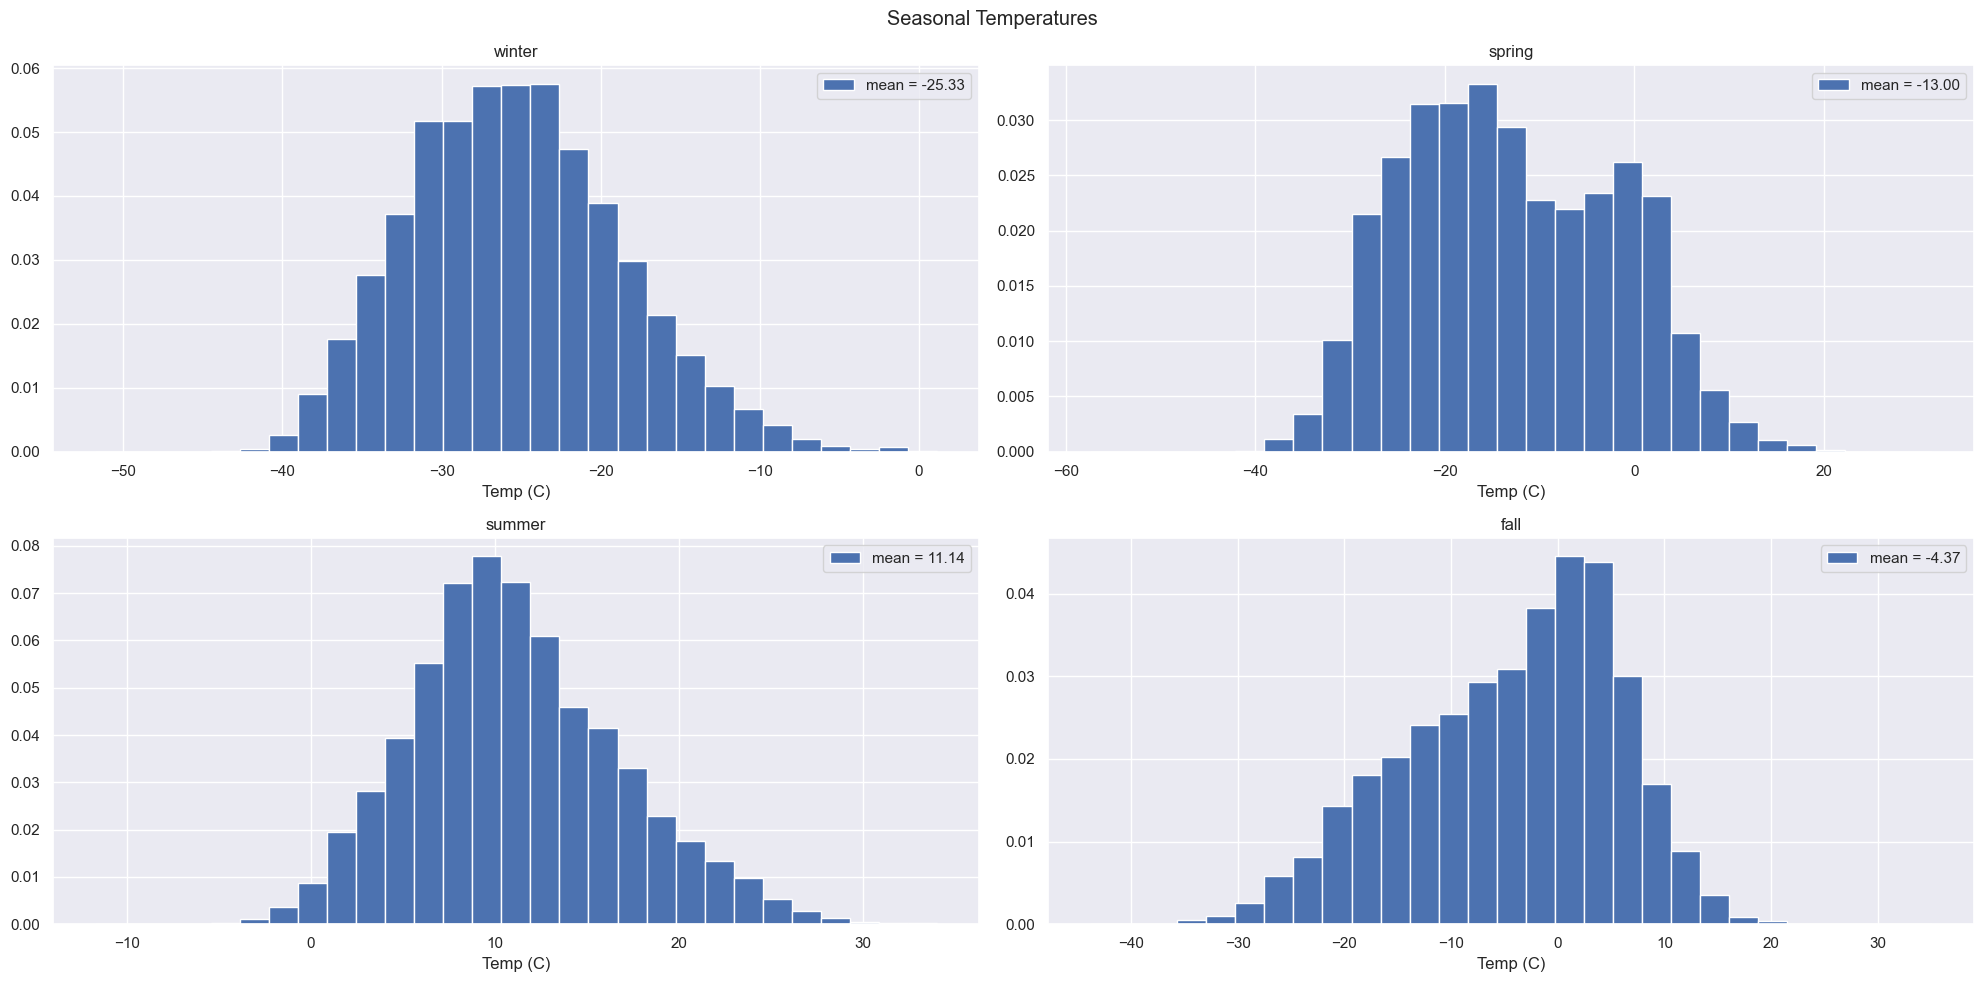

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
ax = axes.flatten()

for i in range(len(ax)):
    if i == 0:
        season = winter.copy()
    elif i == 1:
        season = spring.copy()
    elif i == 2:
        season = summer.copy()
    else:
        season = fall.copy()
    stdn = season["TEMP"].std()
    mean = season["TEMP"].mean()
    low = mean-4*stdn 
    high = mean+4*stdn
    print(low)
    ax[i].hist(season["TEMP"], label=f"mean = {mean:.2f}", bins=np.linspace(low, high, 30), density=True)
    ax[i].legend()
    ax[i].set_xlabel("Temp (C)")
    ax[i].set_title(f"{season['season'].iloc[0]}")
    
    
    

fig.suptitle("Seasonal Temperatures")
plt.tight_layout()
plt.show()

-10.5095330357629
-8.939237151961127
-3.598346630838252
-4.766189665357889


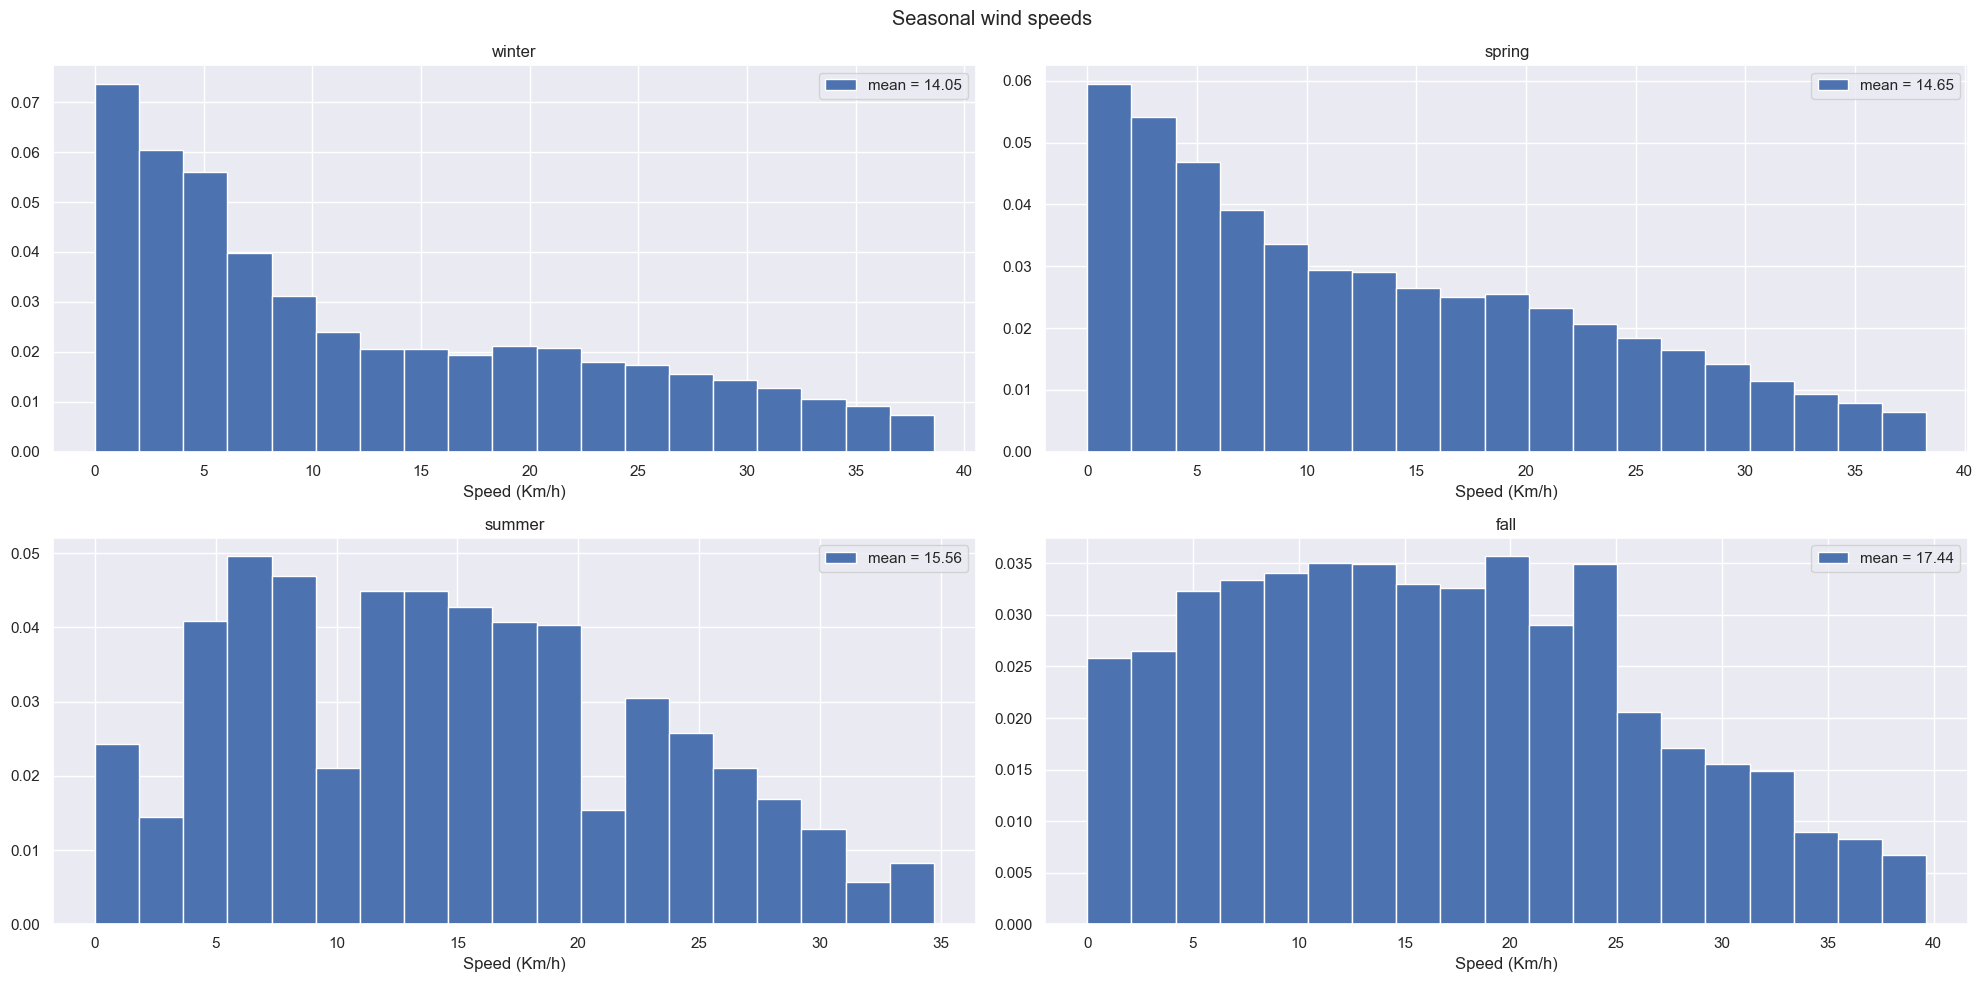

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
ax = axes.flatten()

for i in range(len(ax)):
    if i == 0:
        season = winter.copy()
    elif i == 1:
        season = spring.copy()
    elif i == 2:
        season = summer.copy()
    else:
        season = fall.copy()
    stdn = season["WIND_SPEED"].std()
    mean = season["WIND_SPEED"].mean()
    low = mean - 2*stdn 
    high =mean + 2*stdn
    print(low)
    ax[i].hist(season["WIND_SPEED"], label=f"mean = {mean:.2f}", bins=np.linspace(0, high, 20), density=True)
    ax[i].legend()
    ax[i].set_xlabel("Speed (Km/h)")
    ax[i].set_title(f"{season['season'].iloc[0]}")
    

fig.suptitle("Seasonal wind speeds")
plt.tight_layout()
plt.show()

In [12]:
df["WIND_SPEED"].describe()

count    116207.000000
mean         15.456418
std          11.302735
min           0.000000
25%           6.000000
50%          14.000000
75%          23.000000
max          87.000000
Name: WIND_SPEED, dtype: float64

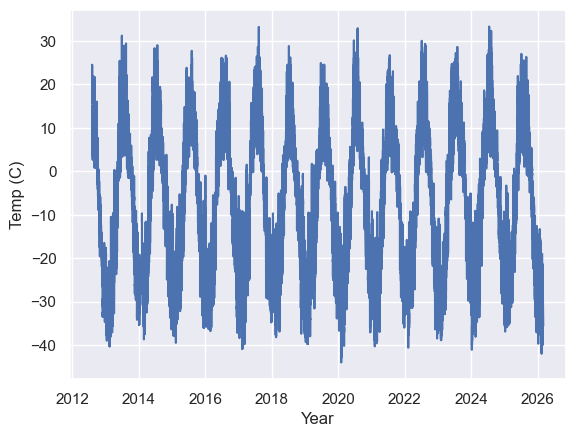

In [13]:
plt.plot(df["ts"], df["TEMP"])
plt.xlabel("Year")
plt.ylabel("Temp (C)")
plt.show()

In [14]:
df["TEMP"].describe()

count    116249.000000
mean         -7.777161
std          15.776440
min         -44.000000
25%         -21.800000
50%          -7.500000
75%           6.000000
max          33.300000
Name: TEMP, dtype: float64

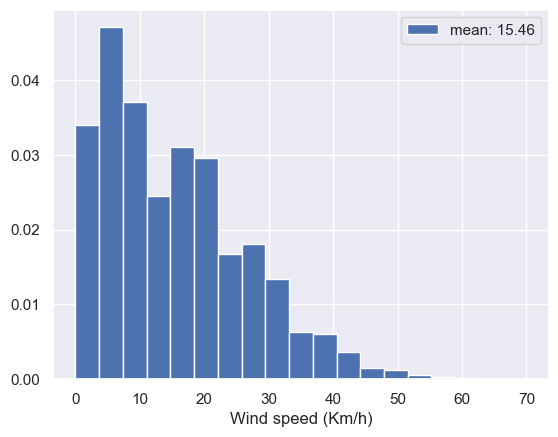

In [20]:
plt.hist(df["WIND_SPEED"], bins=np.linspace(0,70,20), density=True, label=f"mean: {df['WIND_SPEED'].mean():.2f}")
plt.xlabel("Wind speed (Km/h)")
plt.legend()
plt.show()